# Exploratory Data Analysis — Influencer or Observer

**Task.** Binary classification of French Twitter accounts as **influencer (1)** or **observer (0)**
from a single tweet's metadata and text.

This notebook *describes* the data — it does not build features or models. Each section answers one
concrete question, and the findings directly motivate the modelling pipeline:

| Finding | Pipeline consequence |
|---|---|
| Train/test users are 100% disjoint | honest **grouped** cross-validation |
| Label is constant within a user | **per-user smoothing** of predictions |
| Source app is discriminative | **fold-safe source target encoding** |
| Profile colours are ~user-unique | **banned** to avoid identity leakage |
| Text barely separates classes alone | a **fine-tuned CamemBERT**, not TF-IDF |


## 0 · Setup & load

We load the JSON-Lines file and flatten the nested tweet object (`user.*`, `quoted_status.*`) into columns — exactly as the training pipeline does (`pandas.json_normalize`). Set `NROWS = None` to use the full file, or an integer for a quick sample.

In [1]:
import os, sys, json, warnings
from datetime import datetime
import numpy as np
import pandas as pd
from pandas import json_normalize
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

# import the project's canonical paths / constants from src/
_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "exploration" else os.getcwd()
sys.path.insert(0, os.path.join(_ROOT, "src"))
import config

NROWS = 60000   # set to None for the full 154,914-row train file

def load(path, nrows=NROWS):
    df = pd.read_json(path, lines=True, nrows=nrows)
    return json_normalize(df.to_dict(orient="records"))

df = load(config.TRAIN_PATH)
LABEL = "label" if "label" in df.columns else "role"
y = df[LABEL].astype(int)
print(f"loaded {df.shape[0]:,} rows x {df.shape[1]} flattened columns"
      + (f"  (sample NROWS={NROWS})" if NROWS else "  (full file)"))

loaded 60,000 rows x 193 flattened columns  (sample NROWS=60000)


In [2]:
# small helpers reused throughout
def parse_twitter_date(s):
    if not isinstance(s, str) or not s: return None
    try: return datetime.strptime(s, "%a %b %d %H:%M:%S +0000 %Y")
    except Exception: return None

def parse_source_app(s):
    import re
    if not isinstance(s, str) or not s: return "unknown"
    m = re.search(r">([^<]+)<", s)
    return m.group(1).strip() if m else s[:40]

def proxy_user_key(d):
    # direct user ids are stripped; created_at + name is constant per account & near-unique
    created = d.get("user.created_at", pd.Series("", index=d.index)).fillna("").astype(str)
    name    = d.get("user.name",       pd.Series("", index=d.index)).fillna("").astype(str)
    return (created + "||" + name).values

def get_text(row):
    t = row.get("extended_tweet.full_text")
    return t if isinstance(t, str) and t else str(row.get("text", "") or "")

def compare_by_class(series, name, log=False):
    s = pd.to_numeric(series, errors="coerce")
    obs, inf = s[y==0].dropna(), s[y==1].dropna()
    print(f"{name:<22} observer median {obs.median():>12,.1f}  |  influencer median {inf.median():>12,.1f}")
    fig, ax = plt.subplots(figsize=(4.2,3))
    data = [np.log1p(obs) if log else obs, np.log1p(inf) if log else inf]
    ax.boxplot(data, labels=["observer","influencer"], showfliers=False)
    ax.set_title(name + (" (log1p)" if log else "")); plt.show()
    return s

## 1 · Dataset overview

The flattened frame has ~190 columns. Most live under the `quoted_status.*` prefix (the embedded tweet being quoted). We group columns by their JSON prefix to see the structure at a glance.

In [3]:
mem = df.memory_usage(deep=True).sum()/1e6
print(f"in-memory (flattened): {mem:,.1f} MB")
print(f"dtypes: {len(df.select_dtypes('number').columns)} numeric · "
      f"{len(df.select_dtypes('object').columns)} object · "
      f"{len(df.select_dtypes('bool').columns)} bool\n")
prefixes = {}
for c in df.columns:
    prefixes.setdefault(c.split('.')[0] if '.' in c else '(top-level)', []).append(c)
for p in sorted(prefixes, key=lambda k:-len(prefixes[k])):
    print(f"{p:<24}{len(prefixes[p]):>3} cols")

in-memory (flattened): 264.0 MB
dtypes: 49 numeric · 130 object · 12 bool

quoted_status            96 cols
(top-level)              35 cols
user                     32 cols
place                     9 cols
extended_tweet            8 cols
entities                  5 cols
quoted_status_permalink   3 cols
geo                       2 cols
coordinates               2 cols
extended_entities         1 cols


### 1b · Identity fields are stripped — this defines the whole task

There is **no direct user id**. The only `id_str` is the *tweet* id. So there is no legitimate key to aggregate tweets by user — any naive per-user aggregate silently spans the whole dataset (leakage).

In [4]:
for c in ["user.id","user.id_str","user.screen_name"]:
    print(f"{c:<20} present = {c in df.columns}")
print(f"top-level id_str present = {'id_str' in df.columns}  (TWEET id, not user)")

user.id              present = False
user.id_str          present = False
user.screen_name     present = False
top-level id_str present = True  (TWEET id, not user)


## 2 · Label distribution & class balance

Roughly balanced, so plain **accuracy** is a sensible metric and the majority-class baseline is the floor any model must beat.

observer (0)      32,199  (53.66%)
influencer (1)    27,801  (46.34%)
majority-class baseline accuracy: 53.66%


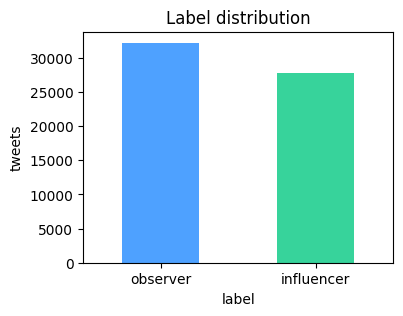

In [5]:
vc = y.value_counts().sort_index()
for k,v in vc.items():
    print(f"{'observer (0)' if k==0 else 'influencer (1)':<16}{v:>8,}  ({v/len(y)*100:5.2f}%)")
print(f"majority-class baseline accuracy: {max(vc)/len(y)*100:.2f}%")
ax = vc.rename({0:'observer',1:'influencer'}).plot(kind='bar', color=['#4ea1ff','#37d39b'], figsize=(4,3))
ax.set_ylabel('tweets'); ax.set_title('Label distribution'); plt.xticks(rotation=0); plt.show()

## 3 · Missingness

Many columns are entirely absent (geo, place, contributors) — a freshly-streamed corpus. The `quoted_status.*` block is absent whenever a tweet quotes nothing (~65% of rows), which is why those features are median-imputed fold-safely rather than zero-filled.

In [6]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss>0]
print(f"{len(miss)} columns have some missingness. Top 20:\n")
for c,f in miss.head(20).items():
    print(f"{f*100:5.1f}%  {c}")

150 columns have some missingness. Top 20:

100.0%  geo
100.0%  quoted_status.coordinates
100.0%  place
100.0%  extended_entities
100.0%  coordinates
100.0%  contributors
100.0%  extended_tweet
100.0%  quoted_status.place
100.0%  quoted_status.geo
100.0%  quoted_status.user.follow_request_sent
100.0%  quoted_status.user.following
100.0%  quoted_status.user.notifications
100.0%  user.utc_offset
100.0%  quoted_status.user.lang
100.0%  quoted_status.user.time_zone
100.0%  quoted_status.user.utc_offset
100.0%  quoted_status.contributors
100.0%  quoted_status_permalink
100.0%  user.notifications
100.0%  user.time_zone


## 4 · User-level structure & label consistency

**The pivotal structural fact.** We reconstruct a proxy user key (`created_at || name`) and check whether a user's tweets ever disagree on the label. They never do — the label is **100% user-constant**. So this is really a *user*-classification task seen through ~5 tweets each, which is exactly what makes **per-user smoothing** valid.

proxy users: 18,432   (30.7% of rows)
tweets/user: mean 3.26 · median 3 · max 12

users with MIXED labels: 0  (0.00%)
=> label is 100% USER-CONSTANT


user-majority ORACLE row-accuracy: 100.00%


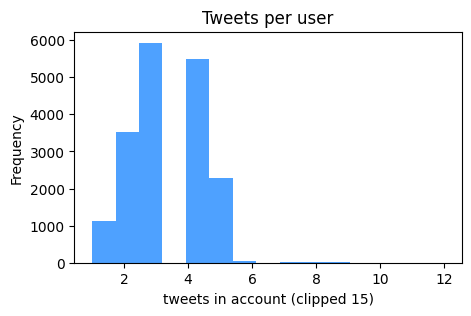

In [7]:
df["_ukey"] = proxy_user_key(df)
tpu = df.groupby("_ukey").size()
print(f"proxy users: {df['_ukey'].nunique():,}   ({df['_ukey'].nunique()/len(df)*100:.1f}% of rows)")
print(f"tweets/user: mean {tpu.mean():.2f} · median {int(tpu.median())} · max {tpu.max()}\n")

mixed = int((df.groupby('_ukey')[LABEL].nunique() > 1).sum())
print(f"users with MIXED labels: {mixed:,}  ({mixed/df['_ukey'].nunique()*100:.2f}%)")
print("=> label is 100% USER-CONSTANT" if mixed==0 else "=> some users are mixed")
oracle = (df.groupby('_ukey')[LABEL].transform(lambda s: s.mode().iloc[0]) == df[LABEL]).mean()
print(f"user-majority ORACLE row-accuracy: {oracle*100:.2f}%")

ax = tpu.clip(upper=15).plot(kind='hist', bins=15, color='#4ea1ff', figsize=(5,3))
ax.set_xlabel('tweets in account (clipped 15)'); ax.set_title('Tweets per user'); plt.show()

## 5 · Train / test user overlap

If test users also appeared in train, memorizing identity would transfer to the leaderboard. They do **not**: the public test is **0% overlapping** — entirely strangers. This is the hard proof that validation must keep each user inside one fold (grouped CV); identity features are dead weight.

In [8]:
test = load(config.TEST_PATH)
tr, te = set(df['_ukey']), set(proxy_user_key(test))
ov = tr & te
print(f"train proxy users: {len(tr):,}")
print(f"test  proxy users: {len(te):,}")
print(f"test users also in train: {len(ov):,}  ({len(ov)/max(len(te),1)*100:.2f}% of test)")
print("=> 0% overlap: the public test is 100% STRANGERS" if len(ov)==0 else "")

train proxy users: 18,432
test  proxy users: 12,199
test users also in train: 3  (0.02% of test)



## 6 · Source app — the strongest honest categorical signal

Which app posted the tweet is informative: **scheduling/automation tools** (TweetDeck, Hootsuite, Buffer, dlvr.it) skew toward influencers; phone apps toward observers. Apps far from the global influencer rate carry signal — captured by the fold-safe **source target encoding**.

distinct apps: 270 · global influencer rate 46.3%

                      tweets  infl_rate
_app                                   
Echobox                  151      100.0
Twitter Media Studio      94      100.0
Hootsuite Inc.           558       91.6
AgoraPulse Manager        96       90.6
TweetDeck                974       89.1
Buffer                   167       87.4
dlvr.it                  394       87.3
WordPress.com            249       78.7
Tweetbot for iΟS          72       77.8
IFTTT                    295       69.2
Twitter for iPhone     19586       53.6
Twitter Web App        17091       44.8


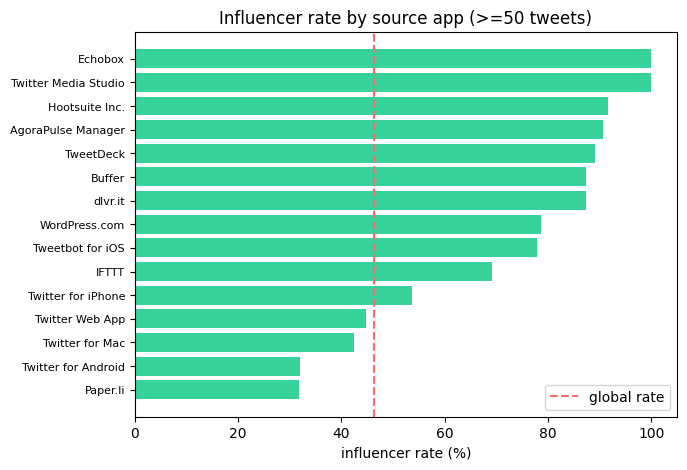

In [9]:
df["_app"] = df["source"].apply(parse_source_app)
stats = df.groupby("_app").agg(tweets=("_app","size"), infl_rate=(LABEL,"mean"))
common = stats[stats.tweets>=50].sort_values("infl_rate", ascending=False)
print(f"distinct apps: {df['_app'].nunique()} · global influencer rate {y.mean()*100:.1f}%\n")
print(common.head(12).assign(infl_rate=lambda d:(d.infl_rate*100).round(1)).to_string())

top = common.head(15)
fig, ax = plt.subplots(figsize=(7,5))
ax.barh(range(len(top)), top.infl_rate*100, color='#37d39b')
ax.set_yticks(range(len(top))); ax.set_yticklabels([a[:24] for a in top.index], fontsize=8)
ax.axvline(y.mean()*100, color='#ff6b6b', ls='--', label='global rate'); ax.invert_yaxis()
ax.set_xlabel('influencer rate (%)'); ax.set_title('Influencer rate by source app (>=50 tweets)')
ax.legend(); plt.show()

## 7 · User-profile numerics by class

The behavioural/account features separate the classes most cleanly. Influencers are **older accounts, tweet far more, and are listed far more often**. (`listed_count` is the single sharpest separator.)

account_age_days       observer median      1,615.0  |  influencer median      2,883.0


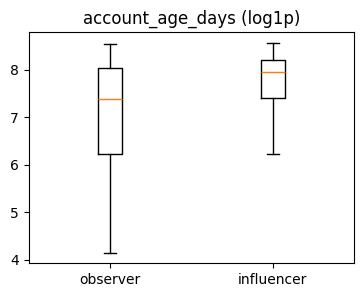

statuses_count         observer median      3,557.0  |  influencer median     20,015.0


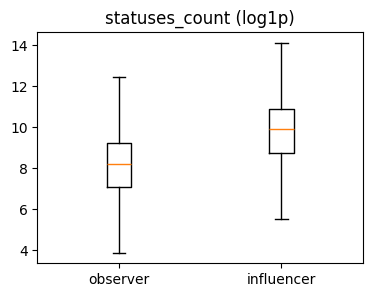

favourites_count       observer median      3,144.0  |  influencer median      6,157.0


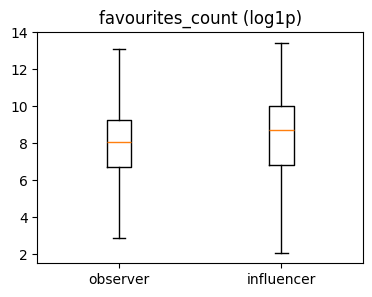

listed_count           observer median          0.0  |  influencer median         24.0


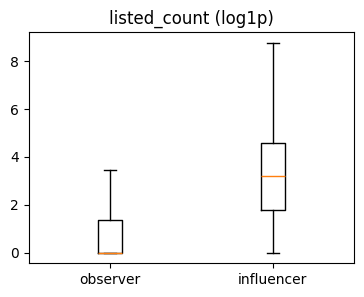

tweets_per_day         observer median          2.9  |  influencer median          8.8


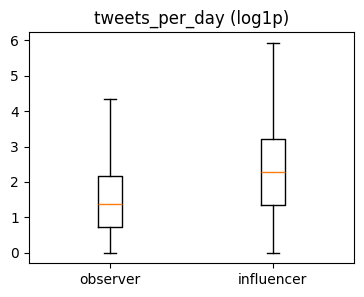

In [10]:
ref = datetime(*config.REF_DATE_YMD)
age = df["user.created_at"].apply(lambda s:(ref-parse_twitter_date(s)).days if parse_twitter_date(s) else np.nan)
_ = compare_by_class(age, "account_age_days", log=True)
_ = compare_by_class(df["user.statuses_count"],    "statuses_count",    log=True)
_ = compare_by_class(df["user.favourites_count"],  "favourites_count",  log=True)
_ = compare_by_class(df["user.listed_count"],      "listed_count",      log=True)
_ = compare_by_class(df["user.statuses_count"]/(age+1), "tweets_per_day", log=True)

## 8 · Text-surface statistics by class

Shallow text features barely separate the classes — medians are nearly identical. This is the evidence that **TF-IDF/surface text is weak**, and the remaining signal needs a real French language model (CamemBERT), not hand-made counts.

text_length            observer median        135.0  |  influencer median        133.0


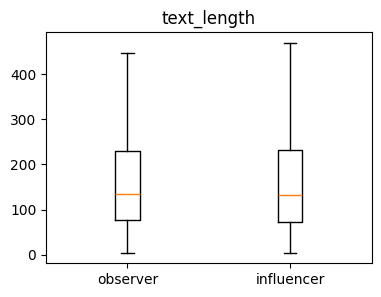

hashtag_count          observer median          0.0  |  influencer median          0.0


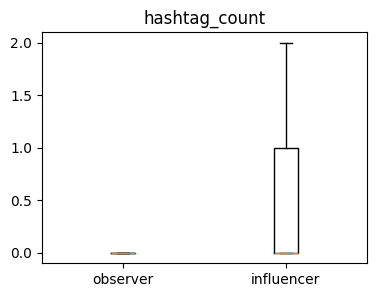

mention_count          observer median          0.0  |  influencer median          0.0


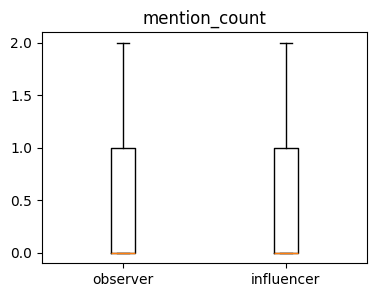

url_count              observer median          0.0  |  influencer median          0.0


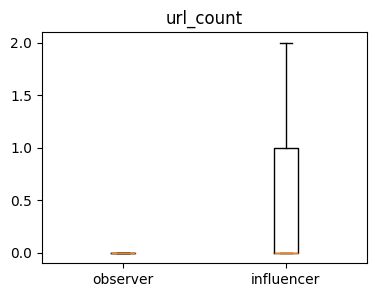

In [11]:
texts = df.apply(get_text, axis=1)
_ = compare_by_class(texts.str.len(),          "text_length")
_ = compare_by_class(texts.str.count(r'#\w+'), "hashtag_count")
_ = compare_by_class(texts.str.count(r'@\w+'), "mention_count")
_ = compare_by_class(texts.str.count('http'),  "url_count")

## 9 · Quoted-tweet presence & stats

The main user's followers are stripped, but the **quoted** user's follower count survives — an indirect influence signal. Present in ~35% of rows.

tweets that quote another tweet: 35.2%
  quote-rate | observer  : 36.0%
  quote-rate | influencer: 34.2%
quoted_followers       observer median     69,481.5  |  influencer median    134,164.0


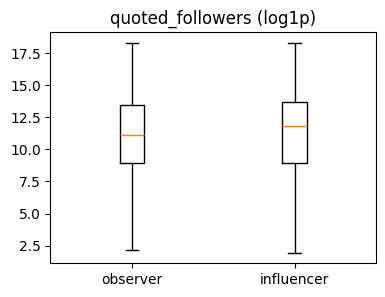

In [12]:
qcol = "quoted_status.user.followers_count"
has_q = df[qcol].notna()
print(f"tweets that quote another tweet: {has_q.mean()*100:.1f}%")
print(f"  quote-rate | observer  : {has_q[y==0].mean()*100:.1f}%")
print(f"  quote-rate | influencer: {has_q[y==1].mean()*100:.1f}%")
_ = compare_by_class(df[qcol], "quoted_followers", log=True)

## 10 · Identity-leakage diagnostic — why colour columns are banned

A feature is an *identity proxy* if it is ~constant within a user but near-unique across users: it lets a model **fingerprint training accounts**, inflating row-wise CV while transferring to nothing. The profile-colour / background-image columns are exactly this, so `config.BANNED_COLUMNS` keeps them out of the feature matrix. (An early submission that used them hit 97% CV but only 0.839 public.)

In [13]:
n_users = df["_ukey"].nunique()
print(f"reference: {n_users:,} proxy users\n")
print(f"{'column':<44}{'distinct vals':>13}")
for c in config.BANNED_COLUMNS:
    if c in df.columns:
        nu = df[c].nunique(dropna=True)
        flag = "  <- high-cardinality identity proxy" if nu > 0.3*n_users else ""
        print(f"{c:<44}{nu:>13,}{flag}")

reference: 18,432 proxy users

column                                      distinct vals
user.profile_background_color                       1,055
user.profile_link_color                             1,817
user.profile_sidebar_border_color                     254
user.profile_sidebar_fill_color                       548
user.profile_text_color                               439
user.profile_background_image_url                      21
user.profile_background_image_url_https                21


## 11 · Numeric signal ranking

Point-biserial correlation of each numeric feature with the label. **`log_listed` dominates** (~0.6), then statuses and account age. Text-surface features are near zero — single features are weak, which is why the models combine them and why text needed a transformer.

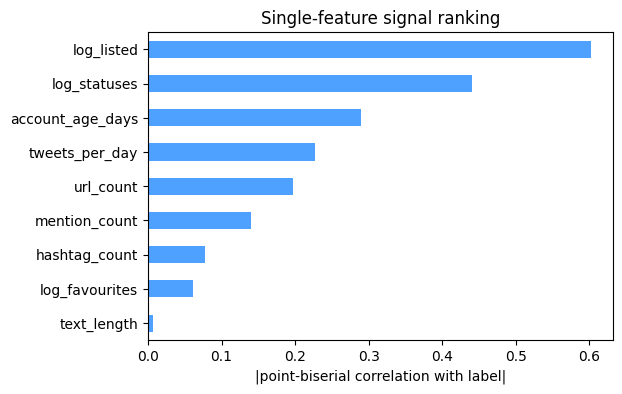

log_listed          0.602
log_statuses        0.440
account_age_days    0.290
tweets_per_day      0.227
url_count           0.197
mention_count       0.140
hashtag_count       0.077
log_favourites      0.062
text_length         0.006


In [14]:
feat = pd.DataFrame({
  "account_age_days": age,
  "log_statuses":   np.log1p(pd.to_numeric(df["user.statuses_count"], errors="coerce")),
  "log_favourites": np.log1p(pd.to_numeric(df["user.favourites_count"], errors="coerce")),
  "log_listed":     np.log1p(pd.to_numeric(df["user.listed_count"], errors="coerce")),
  "tweets_per_day": pd.to_numeric(df["user.statuses_count"], errors="coerce")/(age+1),
  "text_length":    texts.str.len(),
  "hashtag_count":  texts.str.count(r'#\w+'),
  "mention_count":  texts.str.count(r'@\w+'),
  "url_count":      texts.str.count('http'),
})
corr = feat.apply(lambda c: c.corr(y.astype(float))).abs().sort_values(ascending=False)
ax = corr.plot(kind='barh', color='#4ea1ff', figsize=(6,4)); ax.invert_yaxis()
ax.set_xlabel('|point-biserial correlation with label|'); ax.set_title('Single-feature signal ranking'); plt.show()
print(corr.round(3).to_string())

## 12 · Summary — what the EDA tells the pipeline

1. **Disjoint users (§5)** → validate with **StratifiedGroupKFold**; never trust row-wise CV.
2. **User-constant label (§4)** → **per-user smoothing** of predictions (+0.47%, the biggest easy gain).
3. **Source app discriminates (§6)** → **fold-safe source target encoding**.
4. **Colour columns are user-unique (§10)** → **banned** to prevent identity leakage.
5. **Profile numerics carry the signal, text-surface does not (§7–8, §11)** → strong tabular models
   **plus a fine-tuned CamemBERT** (not TF-IDF) for the complementary text signal.

Together these decisions take honest accuracy from ~83.8% (metadata baseline) to **0.856 public — tied #1**.
